In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/feature_engineered_data.csv')
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Tool Wear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure,temp_gap,power,wear_rate,heat_stress,stress_index
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.000000,449.40,0.0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,0.002131,486.15,138.9
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,0.003338,513.76,247.0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,0.004885,410.80,276.5
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,0.006392,420.00,360.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,9.6,47318.0,0.008728,283.20,413.0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,9.5,51897.6,0.010417,302.10,540.6
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,9.6,54943.0,0.013374,320.64,734.8
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,9.7,68288.0,0.017756,470.45,1212.5


In [35]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'Tool Wear Failure',
       'Heat Dissipation Failure', 'Power Failure', 'Overstrain Failure',
       'Random Failure', 'temp_gap', 'power', 'wear_rate', 'heat_stress',
       'stress_index'],
      dtype='object')

In [36]:
df.shape

(10000, 19)

# **Mutual Transformation**

In [37]:
df_model = df.drop(
    columns=[
        "UDI",
        "Product ID",
        "Tool Wear Failure",
        "Heat Dissipation Failure",
        "Power Failure",
        "Overstrain Failure",
        "Random Failure"
    ]
)

In [38]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
 7   temp_gap                 10000 non-null  float64
 8   power                    10000 non-null  float64
 9   wear_rate                10000 non-null  float64
 10  heat_stress              10000 non-null  float64
 11  stress_index             10000 non-null  float64
dtypes: float64(8), int64(3), object(1)
memory usage: 937.6+ KB


# **One Hot Encoding**

In [39]:
df_model = pd.get_dummies(
    df_model,
    columns=["Type"],
    drop_first=True
)

In [40]:
df_model.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temp_gap,power,wear_rate,heat_stress,stress_index,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0.000000,449.40,0.0,False,True
1,298.2,308.7,1408,46.3,3,0,10.5,65190.4,0.002131,486.15,138.9,True,False
2,298.1,308.5,1498,49.4,5,0,10.4,74001.2,0.003338,513.76,247.0,True,False
3,298.2,308.6,1433,39.5,7,0,10.4,56603.5,0.004885,410.80,276.5,True,False
4,298.2,308.7,1408,40.0,9,0,10.5,56320.0,0.006392,420.00,360.0,True,False


In [41]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Air temperature [K]      10000 non-null  float64
 1   Process temperature [K]  10000 non-null  float64
 2   Rotational speed [rpm]   10000 non-null  int64  
 3   Torque [Nm]              10000 non-null  float64
 4   Tool wear [min]          10000 non-null  int64  
 5   Machine failure          10000 non-null  int64  
 6   temp_gap                 10000 non-null  float64
 7   power                    10000 non-null  float64
 8   wear_rate                10000 non-null  float64
 9   heat_stress              10000 non-null  float64
 10  stress_index             10000 non-null  float64
 11  Type_L                   10000 non-null  bool   
 12  Type_M                   10000 non-null  bool   
dtypes: bool(2), float64(8), int64(3)
memory usage: 879.0 KB


# **Split data**

In [42]:
X = df_model.drop(
    columns = ["Machine failure"]
)

y= df_model["Machine failure"]

In [43]:
print(X.shape)
print(y.shape)

(10000, 12)
(10000,)


# **Mututal Information**

In [44]:
from sklearn.feature_selection import mutual_info_classif
mi_score = mutual_info_classif(
    X,
    y,
    random_state=43
)



In [45]:
mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

In [46]:
mi_df = pd.DataFrame(
    {
        "Feature": X.columns,
        "MI Score": mi_scores
    }
)

In [47]:
mi_df = mi_df.sort_values(
    by="MI Score",
    ascending=False
)

mi_df

,Feature,MI Score
3,Torque [Nm],0.046921
6,power,0.044577
2,Rotational speed [rpm],0.037173
9,stress_index,0.034428
8,heat_stress,0.024444
7,wear_rate,0.017850
4,Tool wear [min],0.013453
5,temp_gap,0.011572
1,Process temperature [K],0.004861
0,Air temperature [K],0.004637


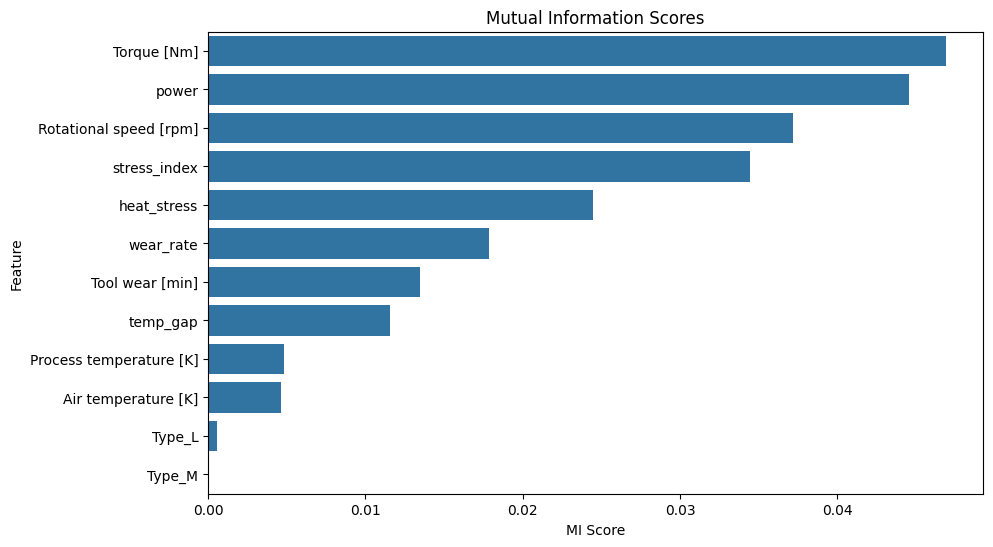

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x="MI Score",
    y="Feature",
    data=mi_df
)

plt.title(
    "Mutual Information Scores"
)

plt.show()

Mutual Information analysis showed that Torque, Power, RPM, and Stress Index were the most informative features for predicting machine failure.

Among the engineered features, power and stress_index ranked among the top predictors, demonstrating that feature engineering successfully extracted additional predictive information beyond the original dataset.

# **Feature Importance**

In [51]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

importances = rf.feature_importances_

importances

array([0.03369541, 0.02753284, 0.14799621, 0.09841074, 0.03805173,
       0.11247799, 0.19006519, 0.06157412, 0.08053049, 0.17919644,
       0.01870352, 0.01176532])

In [52]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

In [53]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
6,power,0.190065
9,stress_index,0.179196
2,Rotational speed [rpm],0.147996
5,temp_gap,0.112478
3,Torque [Nm],0.098411
8,heat_stress,0.080530
7,wear_rate,0.061574
4,Tool wear [min],0.038052
0,Air temperature [K],0.033695
1,Process temperature [K],0.027533


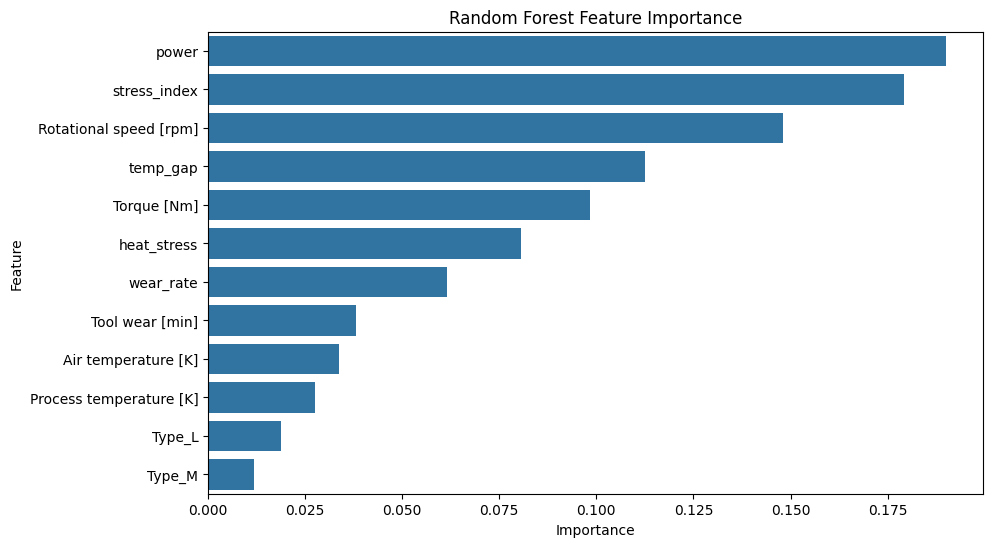

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()